In [9]:
import pandas as pd

file_path=r"C:\Users\ADMIN\project file"


In [10]:
df= pd.read_csv("Student_Performance.csv")

print(df.head())


   student_id  age  gender school_type parent_education  study_hours  \
0           1   14    male      public    post graduate          3.1   
1           2   18  female      public         graduate          3.7   
2           3   17  female     private    post graduate          7.9   
3           4   16   other      public      high school          1.1   
4           5   16  female      public      high school          1.3   

   attendance_percentage internet_access travel_time extra_activities  \
0                   84.3             yes     <15 min              yes   
1                   87.8             yes     >60 min               no   
2                   65.5              no     <15 min               no   
3                   58.1              no   15-30 min               no   
4                   61.0             yes   30-60 min              yes   

  study_method  math_score  science_score  english_score  overall_score  \
0        notes        42.7           55.4           5

In [11]:
df.shape

(25000, 16)

In [12]:
df.columns
df.info
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [13]:
df.isnull().sum()

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

In [14]:
df=df.dropna()

In [15]:
df.head

<bound method NDFrame.head of        student_id  age  gender school_type parent_education  study_hours  \
0               1   14    male      public    post graduate          3.1   
1               2   18  female      public         graduate          3.7   
2               3   17  female     private    post graduate          7.9   
3               4   16   other      public      high school          1.1   
4               5   16  female      public      high school          1.3   
...           ...  ...     ...         ...              ...          ...   
24995       12047   17  female      public              phd          1.8   
24996        1102   16  female     private          diploma          2.7   
24997        4422   19   other     private    post graduate          1.0   
24998        7858   14    male     private          diploma          1.0   
24999       11621   18   other      public        no formal          0.7   

       attendance_percentage internet_access travel_time 

In [16]:
import pandas as pd
df=pd.read_csv("Student_Performance.csv")

#drop useless column
df=df.drop("student_id",axis=1)

#convert catogorial to numeric
df=pd.get_dummies(df,drop_first=True)

df.head()

,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score,gender_male,gender_other,school_type_public,...,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook,final_grade_b,final_grade_c,final_grade_d,final_grade_e,final_grade_f
0,14,3.1,84.3,42.7,55.4,57.0,53.1,True,False,True,...,False,False,True,False,False,False,False,False,True,False
1,18,3.7,87.8,57.6,68.8,64.8,61.3,False,False,True,...,False,False,False,False,True,False,False,True,False,False
2,17,7.9,65.5,84.8,95.0,79.2,89.6,False,False,False,...,False,False,True,False,False,True,False,False,False,False
3,16,1.1,58.1,44.4,27.5,54.7,41.6,False,True,True,...,False,False,True,False,False,False,False,False,True,False
4,16,1.3,61.0,8.9,32.7,30.0,25.4,False,False,True,...,True,False,False,False,False,False,False,False,False,True


Linear Regression

Prediction of overall score

In [17]:
from sklearn.model_selection import train_test_split

x=df.drop("overall_score",axis=1)
y=df["overall_score"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [18]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](29,)","[ 0.01, 2.11, 0.11,...,-18.72,-25.77,-33.28]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](29,)","['age','study_hours','attendance_percentage',...,'final_grade_d', 'final_grade_e','final_grade_f']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,47.82
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,29
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,29


In [19]:
y_pred=lr.predict(x_test)

In [20]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import numpy as np

print("R2 score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("Coefficient:",lr.coef_)

R2 score: 0.9766774948032355
MAE: 2.352355652863744
MSE: 8.524134096915695
RMSE: 2.9196119771154
Coefficient: [ 1.16496373e-02  2.11199420e+00  1.07649572e-01  8.64629079e-02
  9.11406944e-02  8.77964201e-02  6.35036999e-02 -1.01344338e-01
 -4.06464739e-02 -1.25642547e-02  2.78985021e-02  9.12871494e-02
 -3.21295240e-02  1.89634941e-01 -4.47238774e-03 -9.05150182e-02
 -4.01640228e-02 -6.09743414e-02 -3.07437474e-02  5.64608398e-02
 -1.57394329e-01 -6.89407934e-02  1.57329124e-01  1.91898563e-02
 -5.25804765e+00 -1.15949816e+01 -1.87171711e+01 -2.57674552e+01
 -3.32799731e+01]


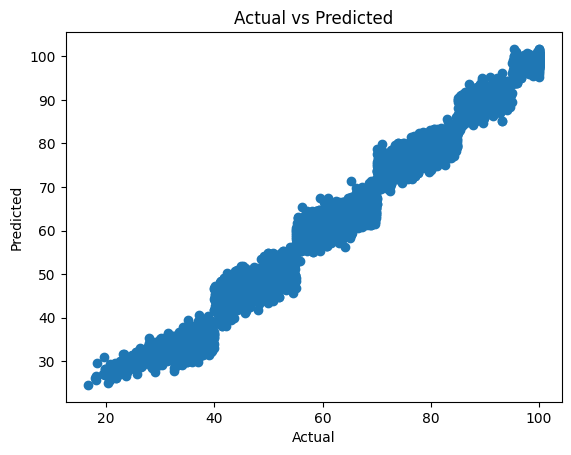

In [21]:
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

Logistic Regression

In [22]:
grade_columns = ['final_grade_b', 'final_grade_c', 'final_grade_d', 'final_grade_e', 'final_grade_f']

In [24]:
import pandas as pd
import numpy as np

df = pd.read_csv("Student_Performance.csv")

In [26]:
print(df.columns)

Index(['student_id', 'age', 'gender', 'school_type', 'parent_education',
       'study_hours', 'attendance_percentage', 'internet_access',
       'travel_time', 'extra_activities', 'study_method', 'math_score',
       'science_score', 'english_score', 'overall_score', 'final_grade'],
      dtype='str')


In [29]:
y = df['final_grade']
X = df.drop(['final_grade'], axis=1)




In [30]:
X = pd.get_dummies(X, drop_first=True)

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [33]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6476
Precision: 0.631371888550995
Recall: 0.6476
F1 Score: 0.6366077311496634
Confusion Matrix:
 [[ 12 193  51   0   0   0]
 [ 41 212 289   0   0   0]
 [ 29  96 867 206   0   0]
 [  0   0 226 855 187   0]
 [  0   0   0 192 858 102]
 [  0   0   0   0 150 434]]


Conclusion:
The Logistic Regression model achieved an accuracy of 75.56% with balanced precision, recall, and F1-score. The confusion matrix shows that most predictions are correct, and errors mainly occur between adjacent grade categories. This indicates that the model is effective in classifying student performance.